# 0. 库函数导入

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import torch.nn as nn
from torch import optim

import torchvision
show = torchvision.transforms.ToPILImage()

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import concurrent.futures as cf
import multiprocessing as mp
import itertools


# Import utility functions
from my_utils import (
    CIFAR_10_MEAN,
    CIFAR_10_STD,
    CIFAR_10_CLASS,
    FIGURE_DIR,
    get_device,
    get_cifar10_data_augmentation,
    train_model,
    train_experiment,
    evaluate,
    plot_loss_curves,
    plot_task3_hyperparameter_effects,
    count_parameters,
    create_learning_rate_scheduler
)
from my_model import (
    LeNet,
    MyCNN
)

# 1. 数据准备

In [2]:
# Set image normalization transforms and download the dataset
os.makedirs('./dataset', exist_ok=True)

# Get light augmentation for LeNet baseline (only flips + crops).
transform_train_light, transform_test = get_cifar10_data_augmentation(style='light')

# Get full augmentation for modern CNN (Task4) — stored here for later use.
transform_train_full, _ = get_cifar10_data_augmentation(style='full')

batch_size = 64

# Load CIFAR-10 with light augmentation for training
full_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_light
)

# Load CIFAR-10 WITHOUT augmentation for validation (clean metrics for early stopping)
full_trainset_clean = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_test
)

# Split into train/val with consistent indices (same split for both datasets)
val_size = int(0.1 * len(full_trainset))
torch.manual_seed(51)
indices = torch.randperm(len(full_trainset)).tolist()
train_indices = indices[val_size:]
val_indices = indices[:val_size]

trainset = torch.utils.data.Subset(full_trainset, train_indices)
valset = torch.utils.data.Subset(full_trainset_clean, val_indices)

print(f"Train set size: {len(trainset)}, Validation set size: {len(valset)}")

# Test set
testset = torchvision.datasets.CIFAR10(
    root='./dataset', train=False, download=True, transform=transform_test
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    valset, batch_size=batch_size, shuffle=False, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train set size: 45000, Validation set size: 5000


CIFAR-10 Dataset Statistics
Full training set:  50000 images
  - Training split: 45000 images
  - Validation split: 5000 images
Test set:           10000 images
Image dimensions:   torch.Size([3, 32, 32])
Number of CIFAR_10_CLASS:  10

Class Distribution:
----------------------------------------
  0: plane      5000 images (10.0%)
  1: car        5000 images (10.0%)
  2: bird       5000 images (10.0%)
  3: cat        5000 images (10.0%)
  4: deer       5000 images (10.0%)
  5: dog        5000 images (10.0%)
  6: frog       5000 images (10.0%)
  7: horse      5000 images (10.0%)
  8: ship       5000 images (10.0%)
  9: truck      5000 images (10.0%)


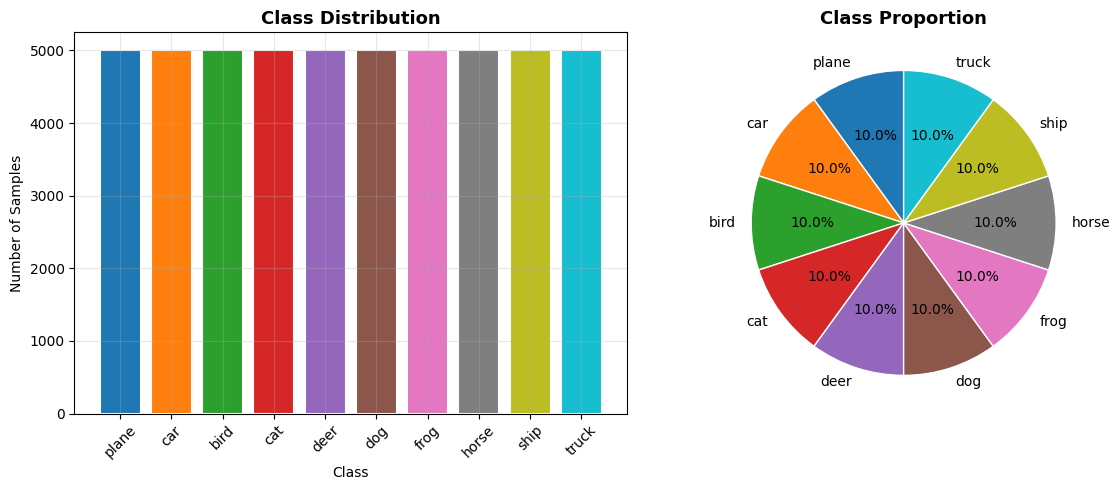

In [3]:
# Data Exploration: Class Distribution and Dataset Statistics
save_path = FIGURE_DIR / 'data_exploration_class_distribution.pdf'

# Collect labels from the full training set
train_labels = [full_trainset[i][1] for i in range(len(full_trainset))]
class_counts = [train_labels.count(i) for i in range(10)]

print("=" * 60)
print("CIFAR-10 Dataset Statistics")
print("=" * 60)
print(f"Full training set:  {len(full_trainset):>5} images")
print(f"  - Training split: {len(trainset):>5} images")
print(f"  - Validation split:{len(valset):>5} images")
print(f"Test set:           {len(testset):>5} images")
print(f"Image dimensions:   {full_trainset[0][0].shape}")
print(f"Number of CIFAR_10_CLASS:  {len(CIFAR_10_CLASS)}")
print()
print("Class Distribution:")
print("-" * 40)
for i, (cls, count) in enumerate(zip(CIFAR_10_CLASS, class_counts)):
    print(f"  {i}: {cls:<8s}  {count:>5} images ({100 * count / len(full_trainset):.1f}%)")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.arange(10))

ax1.bar(CIFAR_10_CLASS, class_counts, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.pie(class_counts, labels=CIFAR_10_CLASS, autopct='%1.1f%%', colors=colors,
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax2.set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


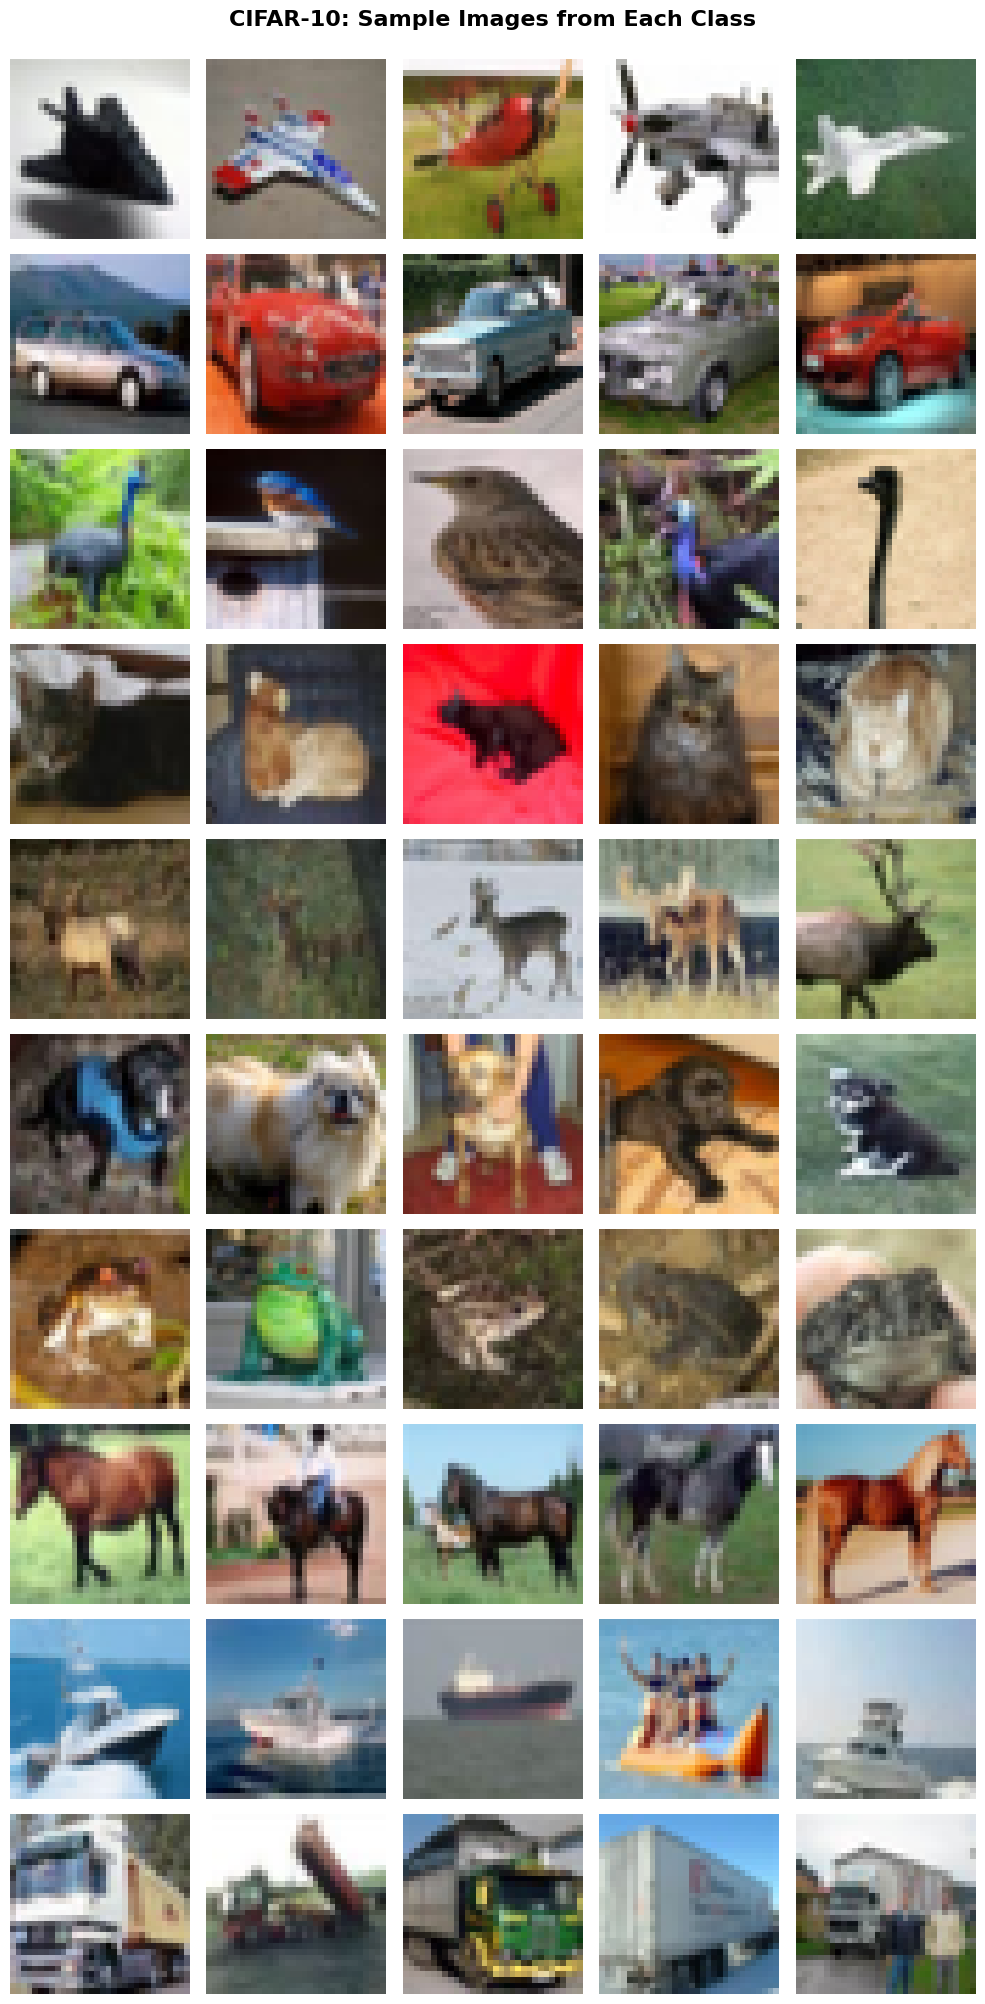

In [4]:
# Data Exploration: Sample Grid from Each Class
save_path = FIGURE_DIR / 'data_exploration_sample_grid.pdf'
samples_per_class = 5

# Load raw training set (without augmentation for clean display)
raw_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR_10_MEAN, CIFAR_10_STD)
    ])
)

# Collect images per class
class_samples = {i: [] for i in range(10)}
for img, label in raw_trainset:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) >= samples_per_class for v in class_samples.values()):
        break

# Plot grid: 10 rows (CIFAR_10_CLASS) x 5 columns (samples)
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 2, 20))
fig.suptitle('CIFAR-10: Sample Images from Each Class', fontsize=16, fontweight='bold', y=1)

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

for i in range(10):
    for j in range(samples_per_class):
        img = class_samples[i][j]
        img_display = img * std_t + mean_t  # Denormalize
        axes[i, j].imshow(img_display.permute(1, 2, 0).clamp(0, 1).numpy())
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(CIFAR_10_CLASS[i], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Per-Channel Pixel Statistics (raw [0, 1] range)
   Red | Mean: 0.4914 | Std: 0.2470 | Min: 0.0000 | Max: 1.0000
 Green | Mean: 0.4822 | Std: 0.2435 | Min: 0.0000 | Max: 1.0000
  Blue | Mean: 0.4465 | Std: 0.2616 | Min: 0.0000 | Max: 1.0000

Overall   | Mean: 0.4734 | Std: 0.2516


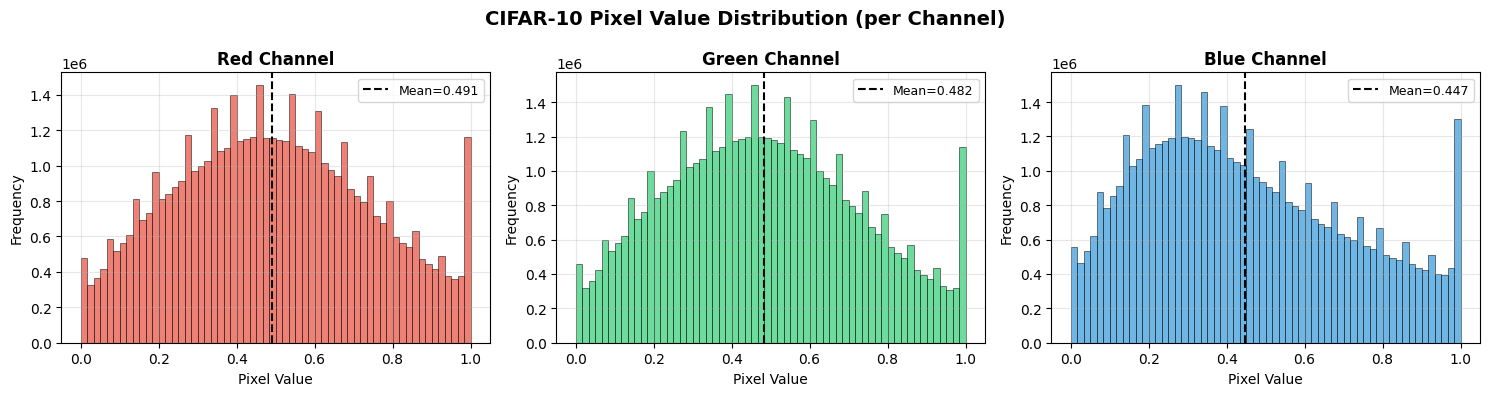

In [5]:
# Data Exploration: Per-Channel Pixel Statistics and Histograms
save_path = FIGURE_DIR / 'data_exploration_pixel_histograms.pdf'
raw_trainset_stats = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.ToTensor()
)

# Stack images
all_pixels = np.stack([np.asarray(raw_trainset_stats[i][0]) for i in range(len(raw_trainset_stats))])

print("=" * 70)
print("Per-Channel Pixel Statistics (raw [0, 1] range)")
print("=" * 70)
channels = ['Red', 'Green', 'Blue']
for i, ch_name in enumerate(channels):
    ch = all_pixels[:, i, :, :]
    print(f"{ch_name:>6} | Mean: {ch.mean():.4f} | Std: {ch.std():.4f} | "
          f"Min: {ch.min():.4f} | Max: {ch.max():.4f}")

print()
print(f"Overall   | Mean: {all_pixels.mean():.4f} | Std: {all_pixels.std():.4f}")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_hist = ['#e74c3c', '#2ecc71', '#3498db']

for i, (ch_name, color) in enumerate(zip(channels, colors_hist)):
    ch_data = all_pixels[:, i, :, :].flatten()
    axes[i].hist(ch_data, bins=60, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].axvline(ch_data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={ch_data.mean():.3f}')
    axes[i].set_title(f'{ch_name} Channel', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('CIFAR-10 Pixel Value Distribution (per Channel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


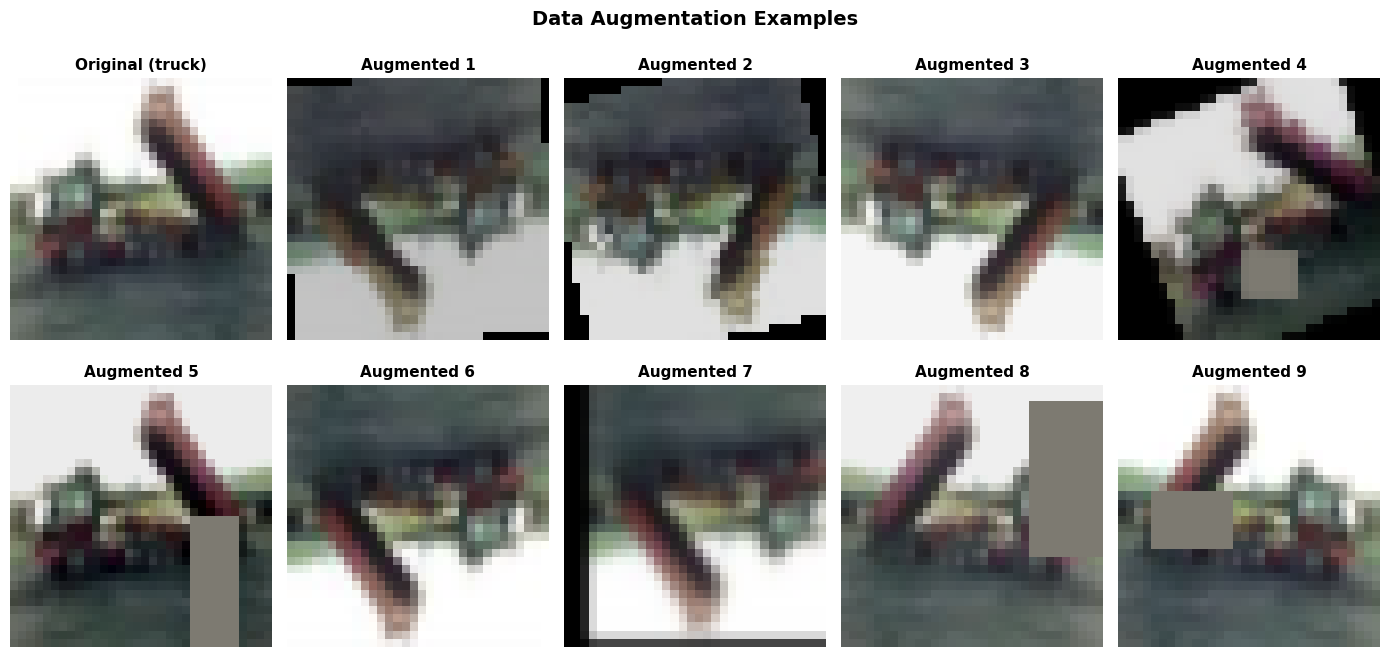

Augmentation visualization saved.
Class: truck


In [6]:
# Data Exploration: Data Augmentation Visualization
# Get a clean PIL image and its label
save_path = FIGURE_DIR / 'data_exploration_augmentation.pdf'
raw_pil_dataset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False
)
sample_img, sample_label = raw_pil_dataset[2]

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
axes = axes.flatten()

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

# Original image (no augmentation)
axes[0].imshow(np.array(sample_img))
axes[0].set_title(f'Original ({CIFAR_10_CLASS[sample_label]})', fontsize=11, fontweight='bold')
axes[0].axis('off')

# 9 augmented versions using transform_train_full (heavy augmentation for visualization)
for i in range(1, 10):
    aug = transform_train_full(sample_img)
    aug_display = aug * std_t + mean_t  # Denormalize
    axes[i].imshow(aug_display.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i].set_title(f'Augmented {i}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Augmentation visualization saved.\nClass: {CIFAR_10_CLASS[sample_label]}")

# 2. 定义用于分类的网络结构

这一部分我们定义用于图像分类的网络结构，实现一个早期的卷积神经网络LeNet。它由两个卷积层和三个全连接层组成。pytorch为我们提供了方便的接口定义神经网络，但我们这里不着重介绍具体的语法，只观察数据是怎样在模型中“流动”的：
- 在`__init__`方法中，我们将上述的卷积层和全连接层初始化为`conv1、conv2`和`fc1、fc2、fc3`；
- 卷积层以`conv1`为例，它的初始化为`Conv2d(3, 6, 5)`，即：3输入通道（RGB图像的三个通道）、6输出通道、5*5大小的卷积核的卷积层。
- 全连接层以`fc1`为例，它的初始化为`Linear(16 * 5 * 5, 120)`，即：从400维映射到120维。
- `forward`方法用于规定数据在模型中的计算过程。输入的形状在传播过程中的变化参见`forward`中的注释。最终，我们得到了一个大小为`[batch size, 10]`的张量（矩阵）。

In [7]:
lenet_baseline = LeNet(dropout=None)
print(lenet_baseline)

param_counts = count_parameters(lenet_baseline)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Total parameters: 62.006K
Trainable parameters: 62.006K, Non-trainable parameters: 0


# 3. 模型训练与测试过程
准备好数据、定义好模型后，我们开始训练过程。为了把一个随机初始化的模型优化成一个“好”的模型，我们还需要定义：
- 损失函数$\mathcal{L}$：损失函数以一般同时以模型的预测$\hat{y}$和真实的标签$y$为输入，输出一个标量。这个标量越小，说明模型在数据上拟合得越好。我们的目的就是要最小化这个损失函数$\mathcal{L}(\hat{y},y).$分类问题常使用交叉熵函数作为损失函数。
- 优化方法：为了最小化损失函数，我们就要使用数学的优化方法找到一组最优的参数（这里的参数即神经网络中卷积层、全连接层等的参数，而非batch size等超参数）。深度学习中一般使用迭代的方式求解，常用的方法有SGD（随机梯度下降）、Adam等。
pytorch库内置了各种优化器，我们无需手动实现梯度下降过程。

下面我们定义用于训练过程的代码。最外层循环控制在整个数据集上训练的次数（即epoch）；内层循环按照以下流程进行：
1. 取出数据（一次取出一个batch）；
2. 将数据送入网络，计算损失函数；
3. 使用损失函数计算梯度，进行反向传播更新参数。

In [8]:
# Set device (GPU if available)
device = get_device()
print(f"Using device: {device}")

# Move model to device
lenet_baseline = lenet_baseline.to(device)

# --- Shared hyperparameters (used across baseline experiment and Task 2) ---
LR = 1e-3
MIN_LR = LR * 0.1
MOMENTUM = 0.9
NUM_EPOCHS = 160
EARLY_STOPPING_PATIENCE = 10
T_0 = 10

# --- Baseline experiment ---
LABEL_SMOOTHING = 0.0  # Will be adjusted in Task3

criterion_baseline = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

weight_decay_baseline = 0.0  # No L2 regularization; will be adjusted in Task2
optimizer_baseline = optim.SGD(
    lenet_baseline.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=weight_decay_baseline
)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_baseline})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create learning rate scheduler config (linear warm-up + cosine annealing with restarts)
scheduler_config_baseline = create_learning_rate_scheduler(
    optimizer_baseline, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS, 
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0
)

# Train the network
save_path_baseline = 'checkpoints/lenet_baseline'
train_losses_baseline, val_accuracies_baseline = train_model(
    model=lenet_baseline,
    train_loader=train_loader,
    criterion=criterion_baseline,
    optimizer=optimizer_baseline,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_baseline,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_baseline
)

print(f"Final training loss: {train_losses_baseline[-1]:.4f}")
if val_accuracies_baseline:
    print(f"Final validation accuracy: {val_accuracies_baseline[-1]:.2f}%")

Using GPU: NVIDIA GeForce RTX 4090
Using device: cuda:0
Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.001, momentum=0.9, weight_decay=0.0)
Epochs: 160 (with early stopping)
Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.001
  Min LR: 0.0001, Total epochs: 160
Training on device: cuda:0
Initial training loss (before training): 2.3051
Initial validation accuracy (before training): 9.68%
--------------------------------------------------
Epoch 1/160: Train Loss: 2.2995, Val Accuracy: 16.60%, Learning Rate: 0.000200, Grad Norm: 0.2184
  -> New best model saved with accuracy: 16.60%
Epoch 2/160: Train Loss: 2.2841, Val Accuracy: 18.04%, Learning Rate: 0.000400, Grad Norm: 0.3059
  -> New best model saved with accuracy: 18.04%
Epoch 3/160: Train Loss: 2.1515, Val Accuracy: 28.66%, Learning Rate: 0.000600, Grad Norm: 1.0294
  -> New best model saved with accuracy: 28.66%
Epoch 4/160: Train Loss: 1.9694, Val Accuracy: 31

训练过程结束后，我们得到了一个在训练集上拟合较好的模型。下面我们要测试它在测试集上表现如何。预测的代码与训练中的正向传播类似，但是不需要计算损失函数（损失函数在实验中仅用于更新参数，预测时参数固定，也就不需要它了）。

预测的流程如下：
1. 取出数据；
2. 正向传播，得到模型的输出结果；
3. 从输出结果中得到模型预测；
4. 和真实标签进行比对，计算性能指标。

注意：模型的输出结果在第2部分中已经说明，为一个`[batch size, 10]`大小的张量（矩阵），每一行是一条数据属于10个类别的概率的相对大小（这一输出也被称为`logits`）。为了得到模型的预测，我们需要对这一输出在每行上取最大值，取得最大值的**位置**就是模型的预测。

In [9]:
# Evaluate on test set
print("\nEvaluating LeNet baseline on test set...")
test_result_baseline = evaluate(
    model=lenet_baseline, test_loader=test_loader, device=device,
    model_name='lenet_baseline', save_plots=True,
)
test_accuracy_baseline = test_result_baseline['accuracy']

# Results comparison
print("\n=== Baseline Results ===")
print(f"  - Best validation accuracy:   {max(val_accuracies_baseline):.2f}%")
print(f"  - Final validation accuracy:  {val_accuracies_baseline[-1]:.2f}%")
print(f"  - Test accuracy:              {test_accuracy_baseline:.2f}%")
print(f"  - ECE (calibration error):    {test_result_baseline['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_baseline['pred_dist_kl']:.6f}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_baseline['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")


Evaluating LeNet baseline on test set...

Comprehensive Evaluation — lenet_baseline

──────────────────────────────────────────────────────────────────────
  Accuracy:                       60.24%
  Average F1:                     0.5947
  ECE (calibration error):        0.0112
  Pred distribution KL:            0.026468
──────────────────────────────────────────────────────────────────────


=== Baseline Results ===
  - Best validation accuracy:   61.12%
  - Final validation accuracy:  59.66%
  - Test accuracy:              60.24%
  - ECE (calibration error):    0.0112
  - Pred distribution KL:       0.026468
  - Best F1:      ship = 0.7213
  - Worst F1:      cat = 0.4272



# Task1：绘制损失函数曲线
损失函数能够量化模型在数据集上的拟合程度，帮助我们了解模型训练的进程。请在`3.模型训练与测试过程`中补充代码，记录训练过程中损失`loss`的变化，使用合适的Python数据类型将其保存，并使用`matplotlib`库将其可视化。可参照以下的代码进行绘图。你可以直接用损失函数可视化的代码覆盖下面的代码块。

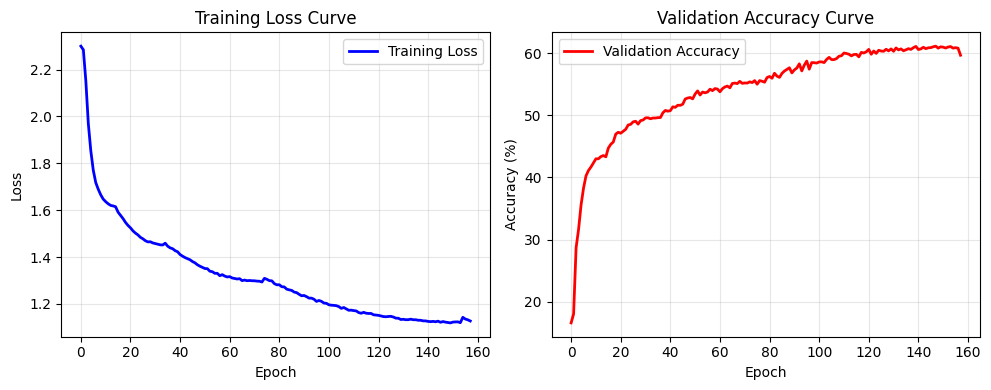

Loss curve saved to figures/lenet_baseline_loss_curve.pdf
Final training loss: 1.1272
Final validation accuracy: 59.66%


In [10]:
# Plot loss curves using utility function
plot_loss_curves(train_losses_baseline, val_accuracies_baseline, FIGURE_DIR / 'lenet_baseline_loss_curve.pdf')

In [11]:
# Clean up GPU memory
del lenet_baseline, optimizer_baseline, criterion_baseline, scheduler_config_baseline
del train_losses_baseline, val_accuracies_baseline
torch.cuda.empty_cache()

请在报告中附上训练过程中损失函数的变化。训练集上的损失越小，说明模型的效果就越好吗？

# Task2: 加入正则化

- $L_2$正则化：请查阅Pytorch[有关SGD优化器的文档](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd)或其它网络资料，修改`3. 模型训练与测试过程`中的代码，尝试为模型的损失函数加入一项$L_2$损失，并在报告中说明你所做的修改。
- Dropout正则化：请查阅Pytorch[有关Dropout层的文档](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#dropout)或其它网络资料，修改`2. 定义用于分类的网络结构`中的代码，在**第一个线性层和第二个线性层之间**加入一个Dropout层，并在报告中说明你所做的修改。
- 在报告中简述两种正则化方法的基本原理。

In [12]:
# Instantiate LeNet with dropout for Task3 experiments
lenet_dropout = LeNet(dropout=0.2)
print(lenet_dropout)

param_counts = count_parameters(lenet_dropout)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total parameters: 62.006K
Trainable parameters: 62.006K, Non-trainable parameters: 0


Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.001, momentum=0.9, weight_decay=1e-05)
Epochs: 160 (with early stopping)
Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.001
  Min LR: 0.0001, Total epochs: 160
Training on device: cuda:0
Initial training loss (before training): 2.3106
Initial validation accuracy (before training): 9.90%
--------------------------------------------------
Epoch 1/160: Train Loss: 2.3005, Val Accuracy: 13.94%, Learning Rate: 0.000200, Grad Norm: 0.2204
  -> New best model saved with accuracy: 13.94%
Epoch 2/160: Train Loss: 2.2794, Val Accuracy: 19.22%, Learning Rate: 0.000400, Grad Norm: 0.3218
  -> New best model saved with accuracy: 19.22%
Epoch 3/160: Train Loss: 2.1308, Val Accuracy: 26.50%, Learning Rate: 0.000600, Grad Norm: 1.0490
  -> New best model saved with accuracy: 26.50%
Epoch 4/160: Train Loss: 1.9990, Val Accuracy: 30.92%, Learning Rate: 0.000800, Grad Norm: 1.7303
  -> 

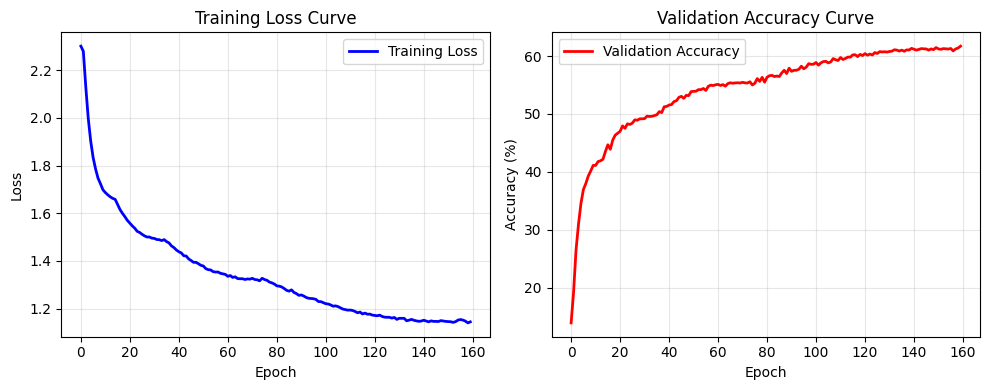

Loss curve saved to figures/lenet_dropout_loss_curve.pdf
Final training loss: 1.1446
Final validation accuracy: 61.70%


In [13]:
# Task2: Train model with Dropout + L2 regularization
# Move model to device
lenet_dropout = lenet_dropout.to(device)

# Dropout experiment: L2 regularization via weight_decay
weight_decay_dropout = 1e-5
optimizer_dropout = optim.SGD(
    lenet_dropout.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=weight_decay_dropout
)
criterion_dropout = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_dropout})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create learning rate scheduler config (separate instance for this optimizer)
scheduler_config_dropout = create_learning_rate_scheduler(
    optimizer_dropout, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0
)

# Train Dropout network with L2 regularization
save_path_dropout = 'checkpoints/lenet_dropout'
train_losses_dropout, val_accuracies_dropout = train_model(
    model=lenet_dropout,
    train_loader=train_loader,
    criterion=criterion_dropout,
    optimizer=optimizer_dropout,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_dropout,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_dropout
)

# Plot loss curves
plot_loss_curves(train_losses_dropout, val_accuracies_dropout, FIGURE_DIR / 'lenet_dropout_loss_curve.pdf')

In [14]:
# Evaluate on test set
print("\nEvaluating LeNet with Dropout on test set...")
test_result_dropout = evaluate(
    model=lenet_dropout, 
    test_loader=test_loader, 
    device=device,
    model_name='lenet_dropout', 
    save_plots=True
)
test_accuracy_dropout = test_result_dropout['accuracy']

# Results comparison
print("\n=== Task2 Results: Dropout + L2 Regularization ===")
print(f"  - Best validation accuracy:   {max(val_accuracies_dropout):.2f}%")
print(f"  - Final validation accuracy:  {val_accuracies_dropout[-1]:.2f}%")
print(f"  - Test accuracy:              {test_accuracy_dropout:.2f}%")
print(f"  - ECE (calibration error):    {test_result_dropout['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_dropout['pred_dist_kl']:.6f}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_dropout['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")

# MC Dropout uncertainty (LeNet with dropout enables this)
if test_result_dropout.get('mc_dropout'):
    md = test_result_dropout['mc_dropout']
    print(f"\nMC Dropout Uncertainty:")
    print(f"  - Avg predictive variance:       {md['variance_mean']:.6f}")
    print(f"  - Accurate variance (mean):      {md.get('accurate_var_mean', 'N/A')}")
    print(f"  - Inaccurate variance (mean):    {md.get('inaccurate_var_mean', 'N/A')}")


Evaluating LeNet with Dropout on test set...

Comprehensive Evaluation — lenet_dropout

[MC Dropout] Evaluating uncertainty ...

──────────────────────────────────────────────────────────────────────
  Accuracy:                       62.04%
  Average F1:                     0.6165
  ECE (calibration error):        0.0334
  Pred distribution KL:            0.005433
  MC Dropout (20 samples):
    Avg predictive variance:      0.010490
    Accurate variance (mean):     0.010467
    Inaccurate variance (mean):   0.010527
──────────────────────────────────────────────────────────────────────


=== Task2 Results: Dropout + L2 Regularization ===
  - Best validation accuracy:   61.70%
  - Final validation accuracy:  61.70%
  - Test accuracy:              62.04%
  - ECE (calibration error):    0.0334
  - Pred distribution KL:       0.005433
  - Best F1:      ship = 0.7391
  - Worst F1:      cat = 0.3905

MC Dropout Uncertainty:
  - Avg predictive variance:       0.010490
  - Accurate variance 

In [15]:
# Clean up GPU memory
del lenet_dropout, optimizer_dropout, criterion_dropout, scheduler_config_dropout
del train_losses_dropout, val_accuracies_dropout
torch.cuda.empty_cache()

# Task3: 调整参数
在`3. 模型训练与测试过程`部分中，我们定义了一些超参数（如`num_epoch`、优化器的`lr`）。调节这些参数，观察损失函数以及模型在测试集上的性能变化，在报告中简要说明这些指标的变化，尝试分析这些超参数对整个模型的影响。

In [16]:
# Task3: Hyperparameter Tuning Experiments (3x3x2x2 grid, 36 experiments)
# Parallel execution with MAX_WORKERS concurrent worker processes.
MAX_WORKERS = 16
DROPOUT = None

# Hyperparameter grid
LR_GRID = [5e-4, 1e-3, 2e-3]
WD_GRID = [0, 1e-5, 2e-5]
LS_GRID = [0, 0.05]
BS_GRID = [16, 64]
# All Task3 experiments use LeNet without dropout for consistent comparison
NUM_EXPERIMENTS = len(LR_GRID) * len(WD_GRID) * len(LS_GRID) * len(BS_GRID)

print("=" * 70)
print("Task3: Hyperparameter Tuning Experiments (Parallel, LeNet + Dropout)")
print(f"  lr           = {LR_GRID}")
print(f"  weight_decay = {WD_GRID}")
print(f"  label_smooth = {LS_GRID}")
print(f"  batch_size   = {BS_GRID}")
print(f"  Total: {NUM_EXPERIMENTS} experiments x {NUM_EPOCHS} epochs each")
print(f"  Workers: {MAX_WORKERS} concurrent on GPU")
print("=" * 70)

# Create output directories
LOG_DIR = Path('logs/task3')
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path('checkpoints/task3')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Prepare argument list for all experiments.
# train_indices / val_indices are the lists from the data-prep cell above.
experiment_args = []
for exp_idx, (lr, wd, ls, bs) in enumerate(
    itertools.product(LR_GRID, WD_GRID, LS_GRID, BS_GRID), 1
):
    experiment_args.append((
        exp_idx, DROPOUT, lr, wd, ls, bs,
        train_indices, val_indices,
        NUM_EPOCHS, T_0, str(CKPT_DIR), str(LOG_DIR)
    ))

results = []

# Use spawn context for safe CUDA multiprocessing
ctx = mp.get_context('spawn')

print(f"\nStarting parallel execution with {MAX_WORKERS} workers...")
print(f"Multiprocessing context: {ctx.get_start_method()}\n")

with cf.ProcessPoolExecutor(max_workers=MAX_WORKERS, mp_context=ctx) as executor:
    # Submit all experiments to the pool
    future_map = {
        executor.submit(train_experiment, *args): args
        for args in experiment_args
    }

    # Collect results as they complete
    for future in cf.as_completed(future_map):
        args = future_map[future]
        exp_idx = args[0]
        try:
            result = future.result()
            results.append(result)
            print(f"[{result['experiment_id']:02d}/{NUM_EXPERIMENTS}] "
                  f"lr={result['learning_rate']}, wd={result['weight_decay']}, "
                  f"ls={result['label_smoothing']}, bs={result['batch_size']} | "
                  f"val_acc={result['best_val_accuracy']:.2f}%, "
                  f"test_acc={result['test_accuracy']:.2f}%, "
                  f"epochs={result['epochs_trained']}")
        except Exception as e:
            print(f"[{exp_idx:02d}/{NUM_EXPERIMENTS}] FAILED: {e}")

# Sort by experiment_id for consistent ordering
results.sort(key=lambda r: r['experiment_id'])

Task3: Hyperparameter Tuning Experiments (Parallel, LeNet + Dropout)
  lr           = [0.0005, 0.001, 0.002]
  weight_decay = [0, 1e-05, 2e-05]
  label_smooth = [0, 0.05]
  batch_size   = [16, 64]
  Total: 36 experiments x 160 epochs each
  Workers: 16 concurrent on GPU

Starting parallel execution with 16 workers...
Multiprocessing context: spawn

Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090


/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090


/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090


...

Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
[29/36] FAILED: cuDNN error: CUDNN_STATUS_EXECUTION_FAILED
Using GPU: NVIDIA GeForce RTX 4090


/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
[21/36] FAILED: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
Using GPU: NVIDIA GeForce RTX 4090


/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
[32/36] FAILED: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 23.65 GiB of which 3.50 MiB is free. Process 3730122 has 2.72 GiB memory in use. Process 3730058 has 2.07 GiB memory in use. Process 2587542 has 492.00 MiB memory in use. Process 2597642 has 11.07 GiB memory in use. Process 2634205 has 498.00 MiB memory in use. Process 2634209 has 498.00 MiB memory in use. Process 2634215 has 498.00 MiB memory in use. Process 2634219 has 482.00 MiB memory in use. Process 2634211 has 482.00 MiB memory in use. Process 2634220 has 498.00 MiB memory in use. Process 2634218 has 498.00 MiB memory in use. Process 2634208 has 92.00 MiB memory in use. Process 2634212 has 482.00 MiB memory in use. Process 2634213 has 480.00 MiB memory in use. Process 2634222 has 480.00 MiB memory in use. Process 2634217 has 490.00 MiB memory in use. Process 


Hyperparameter Tuning Results (sorted by test_accuracy):
 experiment_id  learning_rate  weight_decay  label_smoothing  batch_size  best_val_accuracy  test_accuracy  final_train_loss  epochs_trained optimizer                                           log_file
            16         0.0010       0.00000             0.05          64              68.88          66.96          0.960582              43      Adam      logs/task3/exp_16_lr0.001_wd0_ls0.05_bs64.log
            12         0.0005       0.00002             0.05          64              68.46          66.48          0.954727              78      Adam logs/task3/exp_12_lr0.0005_wd2e-05_ls0.05_bs64.log
             4         0.0005       0.00000             0.05          64              66.60          65.21          0.954985              82      Adam     logs/task3/exp_04_lr0.0005_wd0_ls0.05_bs64.log
             2         0.0005       0.00000             0.00          64              65.74          64.97          0.880464          

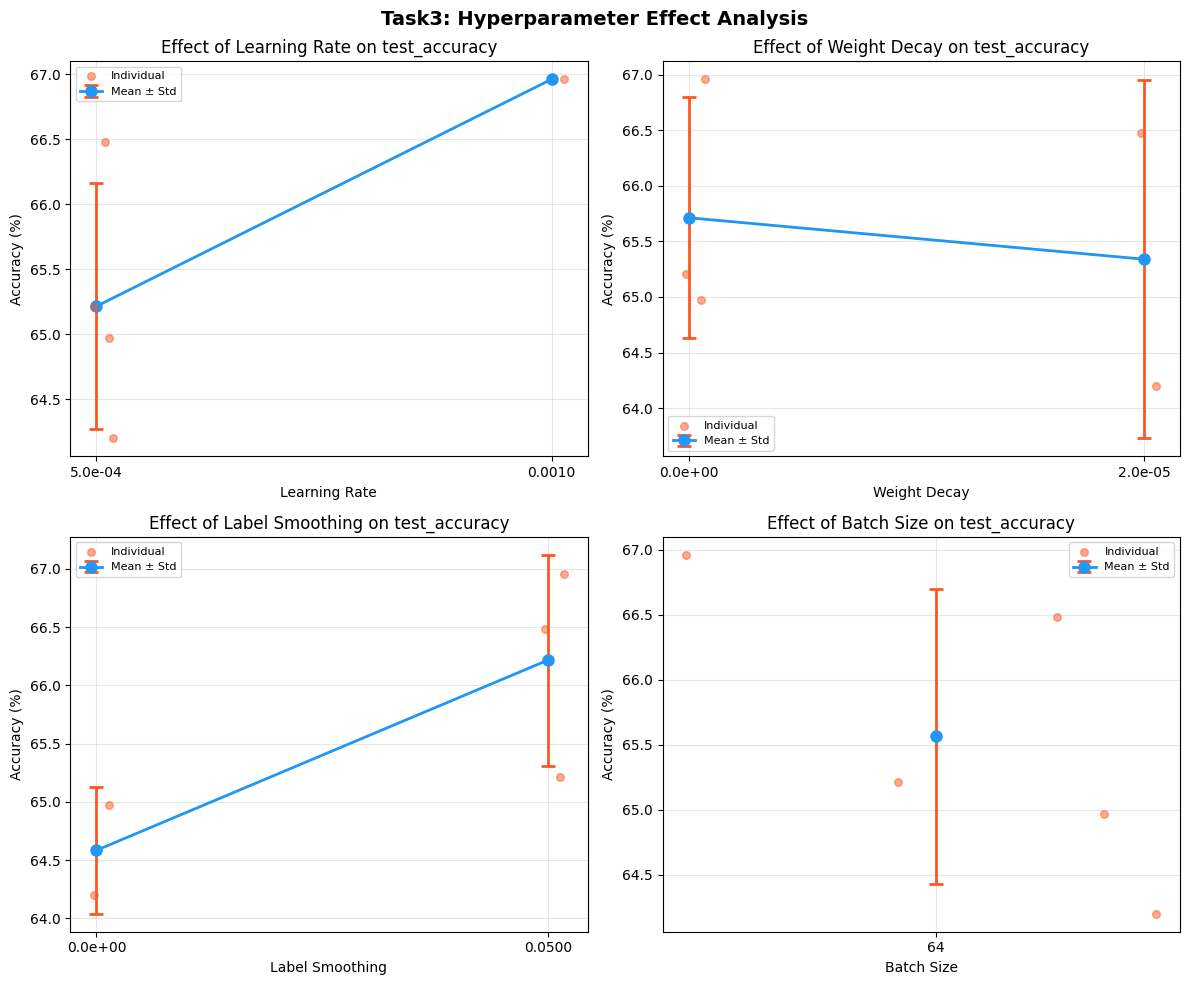

Saved: figures/task3_hyperparameter_effects.pdf

Best Hyperparameter Combination (by test accuracy):
  experiment_id: 16
  learning_rate: 0.001
  weight_decay: 0.0
  label_smoothing: 0.05
  batch_size: 64
  best_val_accuracy: 68.88
  test_accuracy: 66.96
  final_train_loss: 0.9605824318291112
  epochs_trained: 43
  optimizer: Adam
  log_file: logs/task3/exp_16_lr0.001_wd0_ls0.05_bs64.log


In [17]:
# --- Results summary ---
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Hyperparameter Tuning Results (sorted by test_accuracy):")
print("=" * 70)
print(results_df.sort_values('test_accuracy', ascending=False).to_string(index=False))

# Save to CSV
results_df.to_csv('task3_hyperparameter_results.csv', index=False)
print(f"\nResults saved to 'task3_hyperparameter_results.csv'")
print(f"Full logs saved to {LOG_DIR}/")

# --- Comprehensive Visualization ---
# Line charts showing systematic effect of each hyperparameter on test accuracy
plot_task3_hyperparameter_effects(
    results_df,
    save_dir='figures',
    figure_prefix='task3',
    metric='test_accuracy',
)

# --- Best combination (by test_accuracy) ---
best = results_df.loc[results_df['test_accuracy'].idxmax()]
print("\n" + "=" * 70)
print("Best Hyperparameter Combination (by test accuracy):")
print("=" * 70)
for col in results_df.columns:
    print(f"  {col}: {best[col]}")
print("=" * 70)

# Task4: 实现自己的网络
查阅资料（参考：[动手学深度学习](https://zh.d2l.ai/chapter_convolutional-modern/index.html)以及[`torchvision`的模型源码](https://github.com/pytorch/vision/tree/main/torchvision/models)），修改`2. 定义用于分类的网络结构`中的代码，实现一种现代卷积神经网络。与最基础的LeNet相比，你实现的神经网络在性能、训练时间上有何差异？

In [18]:
# Instantiate MyCNN
mycnn = MyCNN(dropout_rate=0.2)
print(mycnn)

param_counts = count_parameters(mycnn)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

MyCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loss function: CrossEntropyLoss (label_smoothing=0.05)
Optimizer: Adam (lr=0.0001, weight_decay=1e-05)
Epochs: 320 (with early stopping)
Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.0001
  Min LR: 1.0000000000000002e-06, Total epochs: 320
Training on device: cuda:0
Initial training loss (before training): 2.3030
Initial validation accuracy (before training): 9.28%
--------------------------------------------------
Epoch 1/320: Train Loss: 1.8975, Val Accuracy: 45.12%, Learning Rate: 0.000020, Grad Norm: 10.8095
  -> New best model saved with accuracy: 45.12%
Epoch 2/320: Train Loss: 1.7047, Val Accuracy: 51.60%, Learning Rate: 0.000040, Grad Norm: 9.8681
  -> New best model saved with accuracy: 51.60%
Epoch 3/320: Train Loss: 1.5827, Val Accuracy: 56.76%, Learning Rate: 0.000060, Grad Norm: 8.2221
  -> New best model saved with accuracy: 56.76%
Epoch 4/320: Train Loss: 1.4759, Val Accuracy: 59.84%, Learning Rate: 0.000080, Grad Norm: 7.253

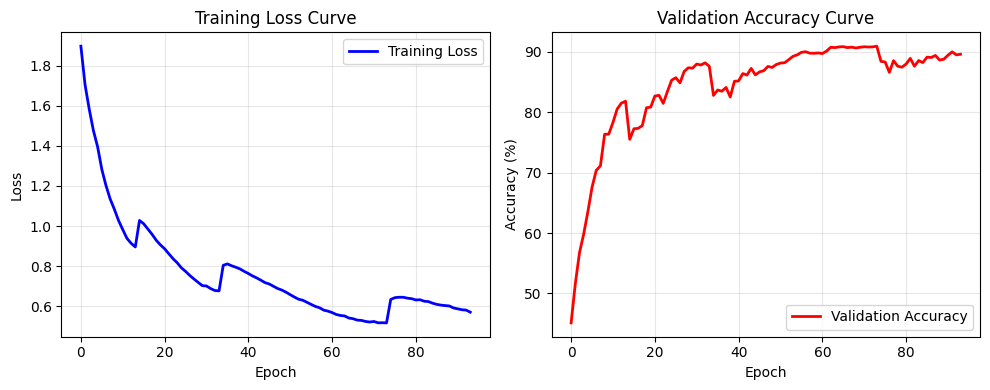

Loss curve saved to figures/mycnn_loss_curve.pdf
Final training loss: 0.5704
Final validation accuracy: 89.62%


In [ ]:
# Task4: MyCNN
# Create DataLoader with full augmentation for modern CNN
full_trainset_full_aug = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_full
)
trainset_full_aug = torch.utils.data.Subset(full_trainset_full_aug, train_indices)
train_loader_full_aug = torch.utils.data.DataLoader(
    trainset_full_aug, batch_size=64, shuffle=True, num_workers=2
)

# Move model to device
mycnn = mycnn.to(device)

# Configure optimizer and loss
LR_MYCNN = 5e-5
MIN_LR_MYCNN = LR_MYCNN * 0.01
WEIGHT_DECAY_MYCNN = 1e-5
LABEL_SMOOTHING_MYCNN = 0.05
NUM_EPOCHS = 320
EARLY_STOPPING_PATIENCE = 20
T_0 = 10

criterion_mycnn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING_MYCNN)
optimizer_mycnn = optim.Adam(mycnn.parameters(), lr=LR_MYCNN, weight_decay=WEIGHT_DECAY_MYCNN)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING_MYCNN})")
print(f"Optimizer: Adam (lr={LR_MYCNN}, weight_decay={WEIGHT_DECAY_MYCNN})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create LR scheduler
scheduler_config_mycnn = create_learning_rate_scheduler(
    optimizer_mycnn,
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR_MYCNN,
    min_lr=MIN_LR_MYCNN,
    T_0=T_0
)

# Train
save_path_mycnn = 'checkpoints/mycnn'
train_losses_mycnn, val_accuracies_mycnn = train_model(
    model=mycnn,
    train_loader=train_loader_full_aug,
    criterion=criterion_mycnn,
    optimizer=optimizer_mycnn,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_mycnn,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_mycnn
)

print(f"Final training loss: {train_losses_mycnn[-1]:.4f}")
if val_accuracies_mycnn:
    print(f"Final validation accuracy: {val_accuracies_mycnn[-1]:.2f}%")

# Plot loss curves
plot_loss_curves(train_losses_mycnn, val_accuracies_mycnn, FIGURE_DIR / 'mycnn_loss_curve.pdf')

In [20]:
# Evaluate on test set
print("\nEvaluating MyCNN on test set...")
test_result_mycnn = evaluate(
    model=mycnn, 
    test_loader=test_loader, 
    device=device,
    model_name='mycnn', 
    save_plots=True
)
test_accuracy_mycnn = test_result_mycnn['accuracy']

# Safely retrieve training history (may vary across runs)
best_val_acc = max(val_accuracies_mycnn)
final_val_acc = val_accuracies_mycnn[-1]
epochs_done = len(train_losses_mycnn)

# Comparison with baseline model
print("\n" + "="*70)
print("Task4 Results:")
print("="*70)
print("MyCNN:")
print(f"  - Best validation accuracy:   {best_val_acc}")
print(f"  - Final validation accuracy:  {final_val_acc}")
print(f"  - Test accuracy:              {test_accuracy_mycnn:.2f}%")
print(f"  - ECE (calibration error):    {test_result_mycnn['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_mycnn['pred_dist_kl']:.6f}")
print(f"  - Epochs trained:             {epochs_done}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_mycnn['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")

# MC Dropout uncertainty (MyCNN has dropout)
if test_result_mycnn.get('mc_dropout'):
    md = test_result_mycnn['mc_dropout']
    print(f"\nMC Dropout Uncertainty:")
    print(f"  - Avg predictive variance:E       {md['variance_mean']:.6f}")
    print(f"  - Accurate variance (mean):      {md.get('accurate_var_mean', 'N/A')}")
    print(f"  - Inaccurate variance (mean):    {md.get('inaccurate_var_mean', 'N/A')}")


Evaluating MyCNN on test set...

Comprehensive Evaluation — mycnn

[MC Dropout] Evaluating uncertainty ...

──────────────────────────────────────────────────────────────────────
  Accuracy:                       89.83%
  Average F1:                     0.8985
  ECE (calibration error):        0.0325
  Pred distribution KL:            0.000423
  MC Dropout (20 samples):
    Avg predictive variance:      0.000613
    Accurate variance (mean):     0.000470
    Inaccurate variance (mean):   0.001880
──────────────────────────────────────────────────────────────────────


Task4 Results:
MyCNN:
  - Best validation accuracy:   90.96
  - Final validation accuracy:  89.62
  - Test accuracy:              89.83%
  - ECE (calibration error):    0.0325
  - Pred distribution KL:       0.000423
  - Epochs trained:             94
  - Best F1:       car = 0.9532
  - Worst F1:      cat = 0.8053

MC Dropout Uncertainty:
  - Avg predictive variance:E       0.000613
  - Accurate variance (mean):      0.0

In [21]:
# Clean up GPU memory
del mycnn, optimizer_mycnn, criterion_mycnn, scheduler_config_mycnn
del train_losses_mycnn, val_accuracies_mycnn, param_counts
torch.cuda.empty_cache()